# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Muhamad Solihin
- **Email:** muhamadsolihin0857@gmail.com
- **ID Dicoding:** DS156B6Y1074

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

**Pertanyaan 1**
> Bagaimana pengaruh musim (*season*) dan kondisi cuaca (*weathersit*) terhadap rata-rata jumlah penyewaan sepeda harian (*cnt*) sepanjang periode 2011–2012, dan kombinasi musim-cuaca mana yang paling perlu diantisipasi dengan penyesuaian stok/armada sepeda?
- **Specific**: fokus pada pengaruh musim & cuaca terhadap jumlah penyewaan harian.
- **Measurable**: dijawab dengan rata-rata `cnt` per kombinasi musim & cuaca.
- **Action-Oriented**: hasilnya jadi dasar keputusan alokasi stok sepeda per musim/cuaca.
- **Relevant**: penyediaan armada yang tepat adalah masalah operasional inti bisnis bike-sharing.
- **Time-bound**: dibatasi pada data historis 2011–2012.

**Pertanyaan 2**
> Bagaimana pola jumlah penyewaan sepeda per jam berbeda antara hari kerja dan hari libur/akhir pekan sepanjang 2011–2012, dan pada rentang jam berapa terjadi puncak permintaan yang perlu diprioritaskan untuk realokasi armada?
- **Specific**: fokus pada pola per jam, dibandingkan antara hari kerja vs hari libur.
- **Measurable**: dijawab dengan rata-rata `cnt` per jam (`hr`).
- **Action-Oriented**: menentukan jam-jam prioritas redistribusi sepeda antar stasiun.
- **Relevant**: efisiensi operasional harian layanan bike-sharing.
- **Time-bound**: dibatasi pada data historis 2011–2012.

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

## Data Wrangling

### Gathering Data

#### Load day_df dan hour_df

In [2]:
day_df = pd.read_csv("data/day.csv")
hour_df = pd.read_csv("data/hour.csv")

print("Dimensi day_df :", day_df.shape)
print("Dimensi hour_df:", hour_df.shape)

Dimensi day_df : (731, 16)
Dimensi hour_df: (17379, 17)


In [3]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- day_df berisi 731 baris (agregasi harian, 2011–2012) dan hour_df berisi 17.379 baris (agregasi per jam) dengan struktur kolom yang sama, kecuali kolom hr (jam) yang hanya ada pada hour_df.
- Kedua dataset menyimpan kolom kategorikal (season, yr, mnth, weekday, weathersit, holiday, workingday) dalam bentuk kode angka, serta kolom cuaca (temp, atemp, hum, windspeed) dalam bentuk ternormalisasi.

### Assessing Data

#### Identifying missing value, tipe data, dan duplikasi

In [5]:
print("=== INFO day_df ===")
day_df.info()

=== INFO day_df ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [6]:
print("=== INFO hour_df ===")
hour_df.info()

=== INFO hour_df ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [7]:
print("Missing value day_df:")
day_df.isna().sum()

Missing value day_df:


instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [8]:
print("Missing value hour_df:")
hour_df.isna().sum()

Missing value hour_df:


instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [9]:
print("Jumlah duplikasi day_df :", day_df.duplicated().sum())
print("Jumlah duplikasi hour_df:", hour_df.duplicated().sum())

Jumlah duplikasi day_df : 0
Jumlah duplikasi hour_df: 0


#### Identifying invalid value & outlier pada kolom numerik

In [10]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [11]:
# Kelembapan (hum) adalah data ternormalisasi (0-1), secara fisik nilai 0%
# sangat tidak wajar untuk cuaca harian -> berpotensi invalid value
print("Baris dengan hum == 0 pada day_df :", (day_df["hum"] == 0).sum())
print("Baris dengan hum == 0 pada hour_df:", (hour_df["hum"] == 0).sum())
day_df[day_df["hum"] == 0]

Baris dengan hum == 0 pada day_df : 1
Baris dengan hum == 0 pada hour_df: 22


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
68,69,2011-03-10,1,0,3,0,4,1,3,0.389091,0.385668,0.0,0.261877,46,577,623


In [12]:
# Cek outlier pada kolom numerik utama dengan pendekatan IQR
num_cols = ["temp", "atemp", "hum", "windspeed", "casual", "registered", "cnt"]

for col in num_cols:
    q1, q3 = day_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((day_df[col] < low) | (day_df[col] > high)).sum()
    print(f"{col:12s}: {n_out} outlier (batas {low:.3f} - {high:.3f})")

temp        : 0 outlier (batas -0.140 - 1.133)
atemp       : 0 outlier (batas -0.068 - 1.015)
hum         : 2 outlier (batas 0.205 - 1.046)
windspeed   : 13 outlier (batas -0.012 - 0.381)
casual      : 44 outlier (batas -855.250 - 2266.750)
registered  : 0 outlier (batas -922.250 - 8195.750)
cnt         : 0 outlier (batas -1054.000 - 10162.000)


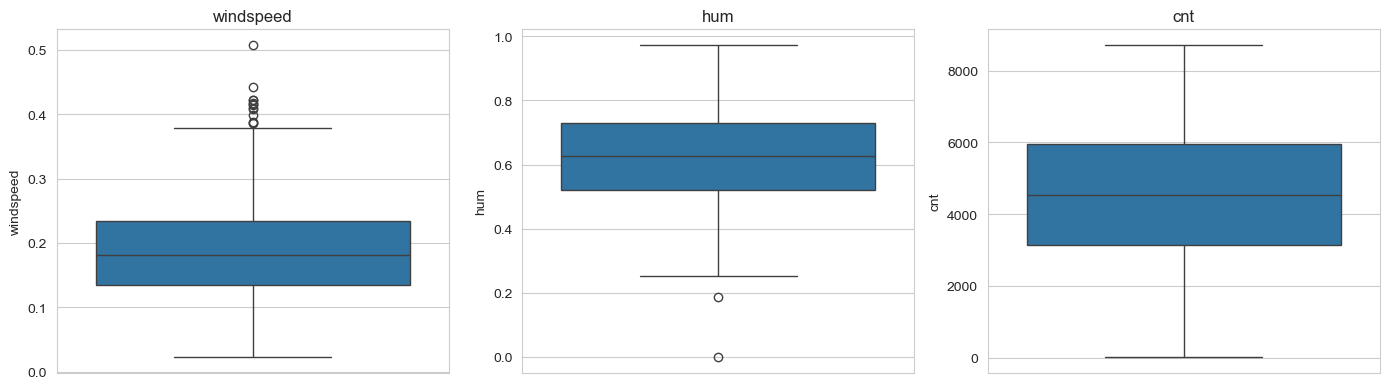

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.boxplot(y=day_df["windspeed"], ax=axes[0]); axes[0].set_title("windspeed")
sns.boxplot(y=day_df["hum"], ax=axes[1]); axes[1].set_title("hum")
sns.boxplot(y=day_df["cnt"], ax=axes[2]); axes[2].set_title("cnt")
plt.tight_layout()
plt.show()

#### Identifying inconsistent value: label musim vs bulan & kategori cuaca

Dokumentasi dataset menyebut `season` 1=Semi, 2=Panas, 3=Gugur, 4=Dingin. Agar label ini tidak dipakai mentah-mentah, kode musim dicocokkan dengan bulan aslinya. Kolom `weathersit` juga dicek apakah semua kodenya sesuai dengan rentang yang diasumsikan (1-3).

In [14]:
# Bulan apa saja yang masuk ke setiap kode musim?
print("Bulan (mnth) per kode season di day_df:")
print(day_df.groupby("season")["mnth"].unique().apply(sorted))
print()
# Kode weathersit yang ada pada kedua dataset
print("Distribusi weathersit day_df :", day_df["weathersit"].value_counts().sort_index().to_dict())
print("Distribusi weathersit hour_df:", hour_df["weathersit"].value_counts().sort_index().to_dict())

Bulan (mnth) per kode season di day_df:
season
1      [1, 2, 3, 12]
2       [3, 4, 5, 6]
3       [6, 7, 8, 9]
4    [9, 10, 11, 12]
Name: mnth, dtype: object

Distribusi weathersit day_df : {1: 463, 2: 247, 3: 21}
Distribusi weathersit hour_df: {1: 11413, 2: 4544, 3: 1419, 4: 3}


**Steps to Take:**
- **Invalid value**: satu baris di day_df dan 22 baris di hour_df memiliki hum (kelembapan) = 0, yang secara fisik tidak masuk akal untuk cuaca harian/jam-jaman di Washington D.C. (seluruh 22 baris hour_df berasal dari satu hari yang sama, 10 Maret 2011) -> perlu diganti menjadi NaN lalu diisi melalui interpolasi berdasarkan urutan waktu (tanggal **dan** jam).
- **Inconsistent value (label musim)**: kode `season` = 1 ternyata mencakup bulan Desember-Maret, kode 2 bulan Maret-Juni, kode 3 bulan Juni-September, dan kode 4 bulan September-Desember. Artinya kode 1 sebenarnya **musim dingin**, 2 **semi**, 3 **panas**, 4 **gugur** -> label pada dokumentasi tidak sesuai data, sehingga pemetaan label harus mengikuti bulan sebenarnya.
- **Inconsistent value (kategori cuaca)**: hour_df memiliki 3 baris dengan `weathersit` = 4 (hujan lebat/salju) yang tidak ada pada day_df -> kategori ini perlu diberi label sendiri agar tidak berubah menjadi NaN dan hilang dari analisis.
- **Tipe data tidak sesuai**: kolom dteday masih bertipe *object* (string), bukan *datetime*, sehingga menyulitkan operasi berbasis tanggal -> perlu dikonversi ke datetime. Kolom kategorikal (season, yr, mnth, weekday, weathersit, holiday, workingday) direpresentasikan sebagai kode angka yang tidak langsung terbaca maknanya -> perlu dipetakan ke label yang mudah dipahami untuk mendukung EDA dan visualisasi.
- Outlier pada windspeed (13 dari 731 hari) ditemukan namun **tidak dihapus**, karena merepresentasikan variasi cuaca alami (hari berangin kencang), bukan kesalahan input, dan justru relevan untuk menjawab Pertanyaan 1.

**Insight:**
- Tidak ditemukan missing value maupun data duplikat pada kedua dataset.
- Ditemukan beberapa masalah kualitas data: **invalid value** (hum = 0), **inconsistent value** (label musim tidak sesuai bulan asli dan kategori cuaca 4 yang tidak terpetakan), serta **tipe data** yang tidak sesuai (dteday sebagai string, kode angka untuk kolom kategorikal).
- Semua masalah tersebut ditangani pada tahap Cleaning Data berikut.

### Cleaning Data

#### Fixing tipe data tanggal, label musim & kategori cuaca

In [15]:
def clean_categorical(df):
    df = df.copy()
    df["dteday"] = pd.to_datetime(df["dteday"])

    # Pemetaan musim mengikuti bulan asli pada data (lihat tahap Assessing Data)
    season_map = {1: "Dingin (Winter)", 2: "Semi (Spring)", 3: "Panas (Summer)", 4: "Gugur (Fall)"}
    weather_map = {1: "Cerah/Berawan Sebagian", 2: "Kabut/Berawan", 3: "Hujan/Salju Ringan", 4: "Hujan Lebat/Salju"}
    yr_map = {0: 2011, 1: 2012}
    weekday_map = {0: "Minggu", 1: "Senin", 2: "Selasa", 3: "Rabu", 4: "Kamis", 5: "Jumat", 6: "Sabtu"}
    workingday_map = {0: "Libur/Akhir Pekan", 1: "Hari Kerja"}

    df["season_label"] = df["season"].map(season_map)
    df["weathersit_label"] = df["weathersit"].map(weather_map)
    df["year_actual"] = df["yr"].map(yr_map)
    df["weekday_label"] = df["weekday"].map(weekday_map)
    df["workingday_label"] = df["workingday"].map(workingday_map)
    return df

day_df = clean_categorical(day_df)
hour_df = clean_categorical(hour_df)

day_df[["dteday", "season_label", "weathersit_label", "year_actual", "weekday_label", "workingday_label"]].head()

print("Label musim kosong :", day_df["season_label"].isna().sum(), "/", hour_df["season_label"].isna().sum())
print("Label cuaca kosong :", day_df["weathersit_label"].isna().sum(), "/", hour_df["weathersit_label"].isna().sum())

Label musim kosong : 0 / 0
Label cuaca kosong : 0 / 0


#### Fixing invalid value (hum = 0)

In [16]:
def fix_invalid_humidity(df):
    df = df.copy()
    # Urutkan berdasarkan tanggal DAN jam agar interpolasi mengikuti urutan waktu yang benar
    sort_cols = ["dteday", "hr"] if "hr" in df.columns else ["dteday"]
    df = df.sort_values(sort_cols).reset_index(drop=True)
    df.loc[df["hum"] == 0, "hum"] = np.nan
    df["hum"] = df["hum"].interpolate(method="linear").ffill().bfill()
    return df

day_df = fix_invalid_humidity(day_df)
hour_df = fix_invalid_humidity(hour_df)

print("hum == 0 di day_df setelah cleaning :", (day_df["hum"] == 0).sum())
print("hum == 0 di hour_df setelah cleaning:", (hour_df["hum"] == 0).sum())
print("Missing value tersisa day_df :", day_df.isna().sum().sum())
print("Missing value tersisa hour_df:", hour_df.isna().sum().sum())
print("Urutan hour_df sudah kronologis:", hour_df["instant"].is_monotonic_increasing)

hum == 0 di day_df setelah cleaning : 0
hum == 0 di hour_df setelah cleaning: 0
Missing value tersisa day_df : 0
Missing value tersisa hour_df: 0
Urutan hour_df sudah kronologis: True


**Insight:**
- Kolom dteday kini bertipe datetime64, sehingga operasi berbasis waktu dan pengurutan menjadi valid.
- Kolom kategorikal kini memiliki label deskriptif (season_label, weathersit_label, weekday_label, workingday_label) tanpa menghapus kode aslinya, sehingga data tetap fleksibel untuk komputasi maupun untuk interpretasi visual.
- Label musim kini mengikuti bulan sebenarnya (kode 1 = Dingin, 2 = Semi, 3 = Panas, 4 = Gugur), dan kategori cuaca 4 (3 baris di hour_df) memiliki label sendiri sehingga tidak ada label kosong.
- Nilai hum yang tidak valid (0) telah digantikan melalui interpolasi linear berdasarkan urutan tanggal dan jam, sehingga tidak ada lagi nilai kelembapan yang mustahil secara fisik. Data juga kembali berurutan secara kronologis.

## Exploratory Data Analysis (EDA)

### Explore statistik ringkas & distribusi penyewaan

In [17]:
day_df[["casual", "registered", "cnt"]].describe()

,casual,registered,cnt
count,731.000000,731.000000,731.000000
mean,848.176471,3656.172367,4504.348837
std,686.622488,1560.256377,1937.211452
min,2.000000,20.000000,22.000000
25%,315.500000,2497.000000,3152.000000
50%,713.000000,3662.000000,4548.000000
75%,1096.000000,4776.500000,5956.000000
max,3410.000000,6946.000000,8714.000000


In [18]:
total_casual = day_df["casual"].sum()
total_registered = day_df["registered"].sum()
total_cnt = day_df["cnt"].sum()

print(f"Total penyewaan casual   : {total_casual:,} ({total_casual/total_cnt:.1%})")
print(f"Total penyewaan registered: {total_registered:,} ({total_registered/total_cnt:.1%})")
print(f"Total penyewaan keseluruhan: {total_cnt:,}")

Total penyewaan casual   : 620,017 (18.8%)
Total penyewaan registered: 2,672,662 (81.2%)
Total penyewaan keseluruhan: 3,292,679


**Insight:**
- Mayoritas penyewaan (~81%) berasal dari pengguna *registered* (member), sedangkan pengguna *casual* menyumbang sekitar 19%. Ini mengindikasikan basis pelanggan yang cukup loyal, namun segmen casual tetap punya potensi konversi menjadi member.

### Explore rata-rata penyewaan berdasarkan musim & cuaca (Pertanyaan 1)

In [19]:
season_order = ["Semi (Spring)", "Panas (Summer)", "Gugur (Fall)", "Dingin (Winter)"]
weather_order = ["Cerah/Berawan Sebagian", "Kabut/Berawan", "Hujan/Salju Ringan"]

by_season = day_df.groupby("season_label")["cnt"].mean().reindex(season_order)
by_weather = day_df.groupby("weathersit_label")["cnt"].mean().reindex(weather_order)

print("Rata-rata cnt per musim:")
print(by_season)
print()
print("Rata-rata cnt per kondisi cuaca:")
print(by_weather)

Rata-rata cnt per musim:
season_label
Semi (Spring)      4992.331522
Panas (Summer)     5644.303191
Gugur (Fall)       4728.162921
Dingin (Winter)    2604.132597
Name: cnt, dtype: float64

Rata-rata cnt per kondisi cuaca:
weathersit_label
Cerah/Berawan Sebagian    4876.786177
Kabut/Berawan             4035.862348
Hujan/Salju Ringan        1803.285714
Name: cnt, dtype: float64


In [20]:
cross_season_weather = (
    day_df.groupby(["season_label", "weathersit_label"])["cnt"]
    .mean()
    .reindex(season_order, level=0)
    .reindex(weather_order, level=1)
    .unstack()
)
cross_season_weather

weathersit_label,Cerah/Berawan Sebagian,Kabut/Berawan,Hujan/Salju Ringan
season_label,,,
Semi (Spring),5548.548673,4236.705882,1169.00
Panas (Summer),5878.257353,5222.479167,2751.75
Gugur (Fall),5043.563107,4654.000000,1961.60
Dingin (Winter),2811.135135,2357.166667,934.75


**Insight:**
- Rata-rata penyewaan tertinggi terjadi pada musim Panas (5.644/hari), diikuti Semi (4.992) dan Gugur (4.728), sementara musim Dingin jauh lebih rendah (2.604/hari), sekitar 54% di bawah musim Panas. Hal ini masuk akal karena suhu rendah menekan minat bersepeda (korelasi temp dengan cnt sekitar 0,63 pada bagian korelasi di bawah).
- Kondisi cuaca cerah/berawan sebagian menghasilkan rata-rata penyewaan tertinggi (4.877/hari), sedangkan cuaca hujan/salju ringan anjlok ke 1.803/hari, sekitar 63% lebih rendah dibanding cuaca cerah.

### Explore pola penyewaan per jam berdasarkan hari kerja vs libur (Pertanyaan 2)

In [21]:
hourly_pattern = hour_df.groupby(["hr", "workingday_label"])["cnt"].mean().unstack()
hourly_pattern.head()

workingday_label,Hari Kerja,Libur/Akhir Pekan
hr,,
0,36.786290,90.800000
1,16.552632,69.508696
2,8.683778,53.171053
3,4.942553,25.775330
4,5.429787,8.264317


In [22]:
top_hours_workday = (
    hour_df[hour_df["workingday"] == 1]
    .groupby("hr")["cnt"].mean()
    .sort_values(ascending=False).head(5)
)
top_hours_offday = (
    hour_df[hour_df["workingday"] == 0]
    .groupby("hr")["cnt"].mean()
    .sort_values(ascending=False).head(5)
)

print("5 jam dengan rata-rata penyewaan tertinggi (Hari Kerja):")
print(top_hours_workday)
print()
print("5 jam dengan rata-rata penyewaan tertinggi (Libur/Akhir Pekan):")
print(top_hours_offday)

5 jam dengan rata-rata penyewaan tertinggi (Hari Kerja):
hr
17    525.290581
18    492.226908
8     477.006048
19    348.401606
16    293.122244
Name: cnt, dtype: float64

5 jam dengan rata-rata penyewaan tertinggi (Libur/Akhir Pekan):
hr
13    372.731602
12    366.259740
14    364.645022
15    358.813853
16    352.727273
Name: cnt, dtype: float64


**Insight:**
- Pada **hari kerja**, penyewaan didominasi dua puncak tajam: pukul **17:00 (525/jam)** dan **18:00 (492/jam)** yaitu jam pulang kantor/sekolah. Serta puncak lebih kecil pukul **08:00 (477/jam)**, yaitu jam berangkat. Pola ini khas *commuting*.
- Pada **libur/akhir pekan**, pola jauh lebih landai dengan puncak tunggal di sekitar tengah hari, yaitu pukul **13:00 (373/jam)** hingga **12:00-15:00** ini mengindikasikan penggunaan untuk rekreasi, bukan commuting.

### Correlation check antar variabel numerik

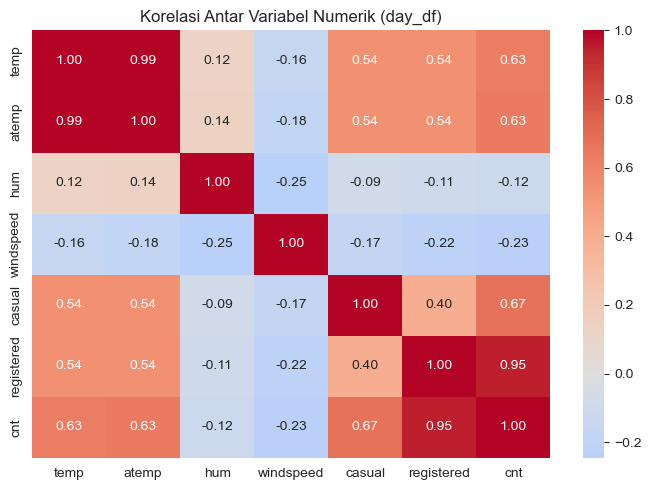

In [23]:
corr_cols = ["temp", "atemp", "hum", "windspeed", "casual", "registered", "cnt"]
corr = day_df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korelasi Antar Variabel Numerik (day_df)")
plt.tight_layout()
plt.show()

**Insight:**
- temp dan atemp berkorelasi kuat positif dengan cnt (>0.6), menegaskan bahwa suhu yang lebih hangat mendorong lebih banyak penyewaan.
- hum (kelembapan) dan windspeed berkorelasi negatif lemah dengan cnt, konsisten dengan temuan bahwa cuaca buruk (hujan, lembap, berangin) menurunkan minat menyewa sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pengaruh musim & cuaca terhadap rata-rata penyewaan harian

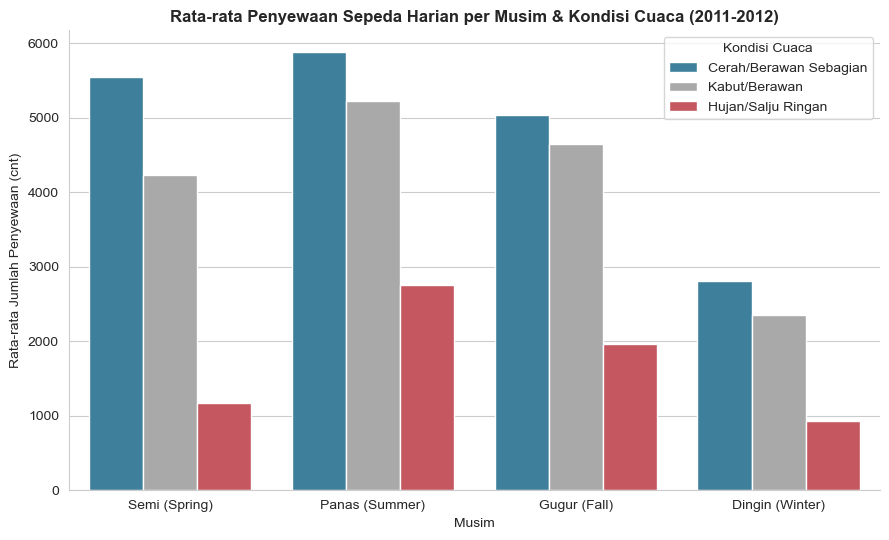

In [24]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(
    data=day_df,
    x="season_label", y="cnt", hue="weathersit_label",
    order=season_order, hue_order=weather_order,
    estimator=np.mean, errorbar=None,
    palette={"Cerah/Berawan Sebagian": "#2E86AB",
             "Kabut/Berawan": "#A9A9A9",
             "Hujan/Salju Ringan": "#D64550"},
    ax=ax,
)
ax.set_title("Rata-rata Penyewaan Sepeda Harian per Musim & Kondisi Cuaca (2011-2012)", fontsize=12, weight="bold")
ax.set_xlabel("Musim")
ax.set_ylabel("Rata-rata Jumlah Penyewaan (cnt)")
ax.legend(title="Kondisi Cuaca", loc="upper right")
sns.despine()
plt.tight_layout()
plt.show()

**Insight:**
- Grafik menegaskan dua pola sekaligus: (1) urutan musim dari yang tertinggi ke terendah adalah Panas > Semi > Gugur > Dingin, dan (2) di setiap musim, cuaca hujan/salju selalu menjadi penyewaan paling rendah. Penurunan paling tajam terjadi pada musim Semi, dari 5.549/hari saat cerah menjadi hanya 1.169/hari saat hujan (turun sekitar 79%).
- Warna dipilih dengan skema yang bermakna (biru = cerah, abu = mendung, merah = hujan) agar pembaca langsung memahami tingkat keparahan cuaca tanpa perlu membaca legenda berulang kali; sumbu y bar chart dimulai dari nol sehingga tinggi batang dapat dibandingkan secara jujur. Ini menerapkan prinsip integritas visual.

### Pertanyaan 2: Pola penyewaan per jam, hari kerja vs libur/akhir pekan

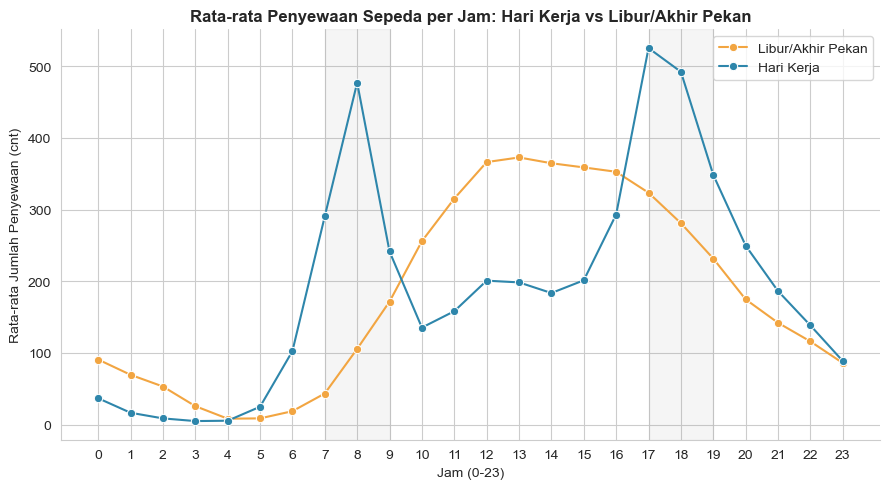

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(
    data=hour_df, x="hr", y="cnt", hue="workingday_label",
    estimator=np.mean, errorbar=None, marker="o",
    palette={"Hari Kerja": "#2E86AB", "Libur/Akhir Pekan": "#F2A541"},
    ax=ax,
)
ax.set_title("Rata-rata Penyewaan Sepeda per Jam: Hari Kerja vs Libur/Akhir Pekan", fontsize=12, weight="bold")
ax.set_xlabel("Jam (0-23)")
ax.set_ylabel("Rata-rata Jumlah Penyewaan (cnt)")
ax.set_xticks(range(0, 24))
ax.axvspan(7, 9, color="grey", alpha=0.08)
ax.axvspan(17, 19, color="grey", alpha=0.08)
ax.legend(title="")
sns.despine()
plt.tight_layout()
plt.show()

**Insight:**
- Grafik hari kerja (biru) menunjukkan pola bimodal khas *commuting*, dengan dua puncak tajam yang ditandai area abu-abu: pagi (07:00-09:00) dan sore (17:00-19:00), sedangkan grafik libur/akhir pekan (oranye) jauh lebih landai dengan satu puncak lebar di siang hari.
- Kedua pertanyaan bisnis terjawab: pertanyaan 1 melalui grafik musim-cuaca di atas, pertanyaan 2 melalui grafik pola per jam ini dimana masing-masing pertanyaan dijawab oleh minimal satu visualisasi sebagaimana disyaratkan.

## Analisis Lanjutan (Opsional)

**Teknik**: *Binning* & *Manual Grouping* (tanpa algoritma *machine learning*).

Untuk memperdalam Pertanyaan 2, jam (`hr`) dikelompokkan secara manual menjadi 5 kategori waktu (*time-of-day binning*) berdasarkan pemahaman domain jam operasional harian, lalu disilangkan dengan kategori hari kerja/libur untuk melihat segmen waktu mana yang paling potensial untuk redistribusi armada.

In [26]:
bins = [-1, 5, 9, 14, 18, 23]
labels = ["Dini Hari (00-05)", "Pagi (06-09)", "Siang (10-14)", "Sore (15-18)", "Malam (19-23)"]
hour_df["time_of_day"] = pd.cut(hour_df["hr"], bins=bins, labels=labels)

segment_summary = (
    hour_df.groupby(["time_of_day", "workingday_label"], observed=True)["cnt"]
    .mean()
    .unstack()
    .reindex(labels)
)
segment_summary

workingday_label,Hari Kerja,Libur/Akhir Pekan
time_of_day,,
Dini Hari (00-05),16.435096,42.998534
Pagi (06-09),277.909274,85.000000
Siang (10-14),175.319517,334.972294
Sore (15-18),378.024072,329.088841
Malam (19-23),202.301205,150.093043


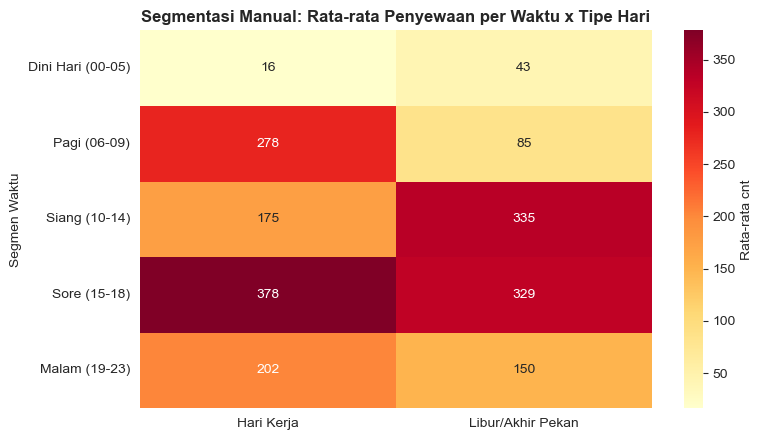

In [27]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(segment_summary, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "Rata-rata cnt"})
ax.set_title("Segmentasi Manual: Rata-rata Penyewaan per Waktu x Tipe Hari", fontsize=12, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Segmen Waktu")
plt.tight_layout()
plt.show()

**Insight:**
- Segmen **Sore (15-18) di Hari Kerja** menjadi kelompok dengan permintaan tertinggi (rata-rata 378/jam), diikuti **Siang (10-14) di Libur/Akhir Pekan** (335/jam). Sebaliknya, **Dini Hari** pada kedua tipe hari konsisten menjadi segmen dengan permintaan paling rendah (<45/jam).
- Segmentasi manual ini relevan untuk operasional: armada sepeda dapat diprioritaskan/direlokasi menjelang segmen Sore hari kerja dan Siang akhir pekan, sementara jendela Dini Hari bisa dimanfaatkan untuk maintenance armada tanpa mengorbankan ketersediaan pada jam sibuk.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Musim dan cuaca berpengaruh besar terhadap rata-rata penyewaan harian. Musim **Panas** mencatat rata-rata tertinggi (5.644/hari) sementara musim **Dingin** terendah (2.604/hari). Di semua musim, cuaca **hujan/salju ringan** selalu menekan penyewaan drastis (rata-rata 1.803/hari, ~63% lebih rendah dibanding cuaca cerah 4.877/hari), kombinasi terburuk terlihat pada Dingin + Hujan (935/hari), dan kombinasi terbaik pada Panas + Cerah (5.878/hari).
- **Conclusion pertanyaan 2:** Pola per jam berbeda tajam antara hari kerja dan libur/akhir pekan. Hari kerja menunjukkan pola bimodal commuting dengan puncak pukul **17:00-18:00** (492-525 penyewaan/jam) dan puncak kedua pukul **08:00** (477/jam). Libur/akhir pekan menunjukkan pola unimodal yang lebih landai dengan puncak di sekitar **12:00-15:00** (~359-373/jam). Segmentasi manual mempertegas bahwa **Sore hari kerja** dan **Siang akhir pekan** adalah dua segmen waktu dengan permintaan tertinggi.

**Recommendations**
- Tingkatkan alokasi/stok sepeda menjelang musim **Semi-Panas** saat permintaan tertinggi, dan jadwalkan maintenance armada yang lebih intensif pada musim **Dingin** saat permintaan secara alami rendah.
- Siapkan sistem peringatan dini berbasis prakiraan cuaca: saat cuaca diprediksi **hujan/salju**, kurangi jumlah sepeda yang didistribusikan ke stasiun agar tidak terjadi kelebihan pasokan yang tidak terpakai.
- Prioritaskan redistribusi/rebalancing sepeda antar-stasiun menjelang jam **07:00-09:00** dan **17:00-19:00** pada hari kerja untuk mengantisipasi lonjakan commuting, serta menjelang **12:00-15:00** pada akhir pekan untuk permintaan rekreasi.
- Manfaatkan jendela **Dini Hari (00:00-05:00)** yang permintaannya paling rendah di semua tipe hari sebagai waktu optimal untuk maintenance rutin armada tanpa mengganggu ketersediaan pada jam sibuk.

### Menyimpan Data Bersih untuk Dashboard

In [28]:
import os

os.makedirs("dashboard", exist_ok=True)

# Data per jam (dipakai untuk Pertanyaan 2, analisis lanjutan, dan KPI dashboard)
hour_df.to_csv("dashboard/main_data.csv", index=False)
# Data per hari (dipakai untuk Pertanyaan 1 agar konsisten dengan notebook)
day_df.to_csv("dashboard/day_data.csv", index=False)

print("main_data.csv berhasil disimpan, shape:", hour_df.shape)
print("day_data.csv berhasil disimpan, shape :", day_df.shape)

main_data.csv berhasil disimpan, shape: (17379, 23)
day_data.csv berhasil disimpan, shape : (731, 21)
